## Videos Models

In [1]:
import torch
import diffusers
import transformers
import cv2

In [2]:
path = "/content/elmo.jpg"

## Generating Video with Diffusion

In [3]:
from diffusers import StableVideoDiffusionPipeline

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
pipe = StableVideoDiffusionPipeline.from_pretrained("stabilityai/stable-video-diffusion-img2vid-xt",
                                                    torch_dtype=torch.float16, # Out of memory
                                                    variant="fp16")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/496 [00:00<?, ?B/s]

Fetching 9 files:   0%|          | 0/9 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/984 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/3.05G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/196M [00:00<?, ?B/s]

image_encoder/model.fp16.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


In [5]:
pipe.enable_model_cpu_offload()

In [6]:
from diffusers.utils import load_image, export_to_video

In [7]:
image = load_image(path)

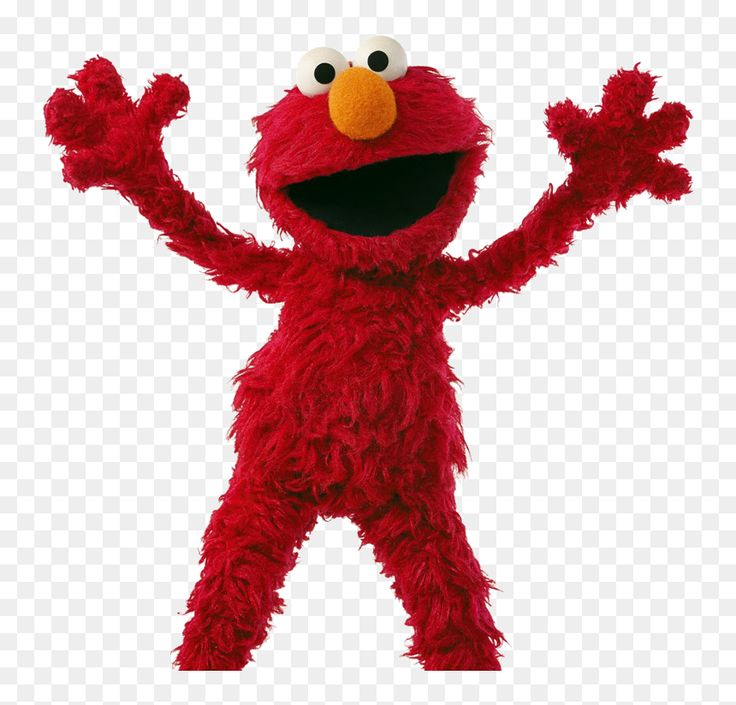

In [8]:
image

In [10]:
import torch
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms.functional as TF

def center_crop_resize(img, crop_ratio=0.6, out_size=(512, 512)):
    """
    img: PIL Image or tensor (C,H,W)
    crop_ratio: portion of the center to keep (0.6 means 60% of width & height)
    out_size: final resize size (h, w)
    """
    # Convert to tensor if needed
    if not torch.is_tensor(img):
        img = TF.to_tensor(img)

    C, H, W = img.shape

    # Compute crop box
    crop_h = int(H * crop_ratio)
    crop_w = int(W * crop_ratio)

    top = (H - crop_h) // 2
    left = (W - crop_w) // 2

    # Crop
    cropped = img[:, top:top + crop_h, left:left + crop_w]

    # Resize
    resized = F.interpolate(
        cropped.unsqueeze(0),
        size=out_size,
        mode="bilinear",
        align_corners=False
    ).squeeze(0)

    return resized


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

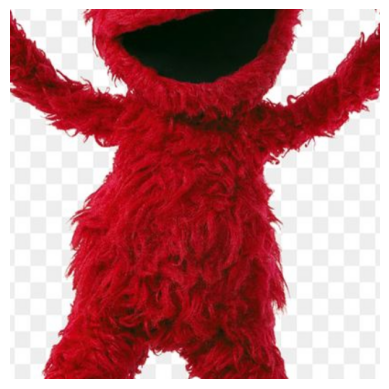

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(path)  # or your path

cropped = center_crop_resize(img, crop_ratio=0.55, out_size=(512, 512))

plt.imshow(cropped.permute(1, 2, 0))
plt.axis("off")


In [25]:
!nvidia-smi

Tue Jan 20 18:59:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             63W /  400W |     949MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [9]:
generator = torch.manual_seed(42) # to make the results reproducible

In [12]:
frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

  0%|          | 0/25 [00:00<?, ?it/s]

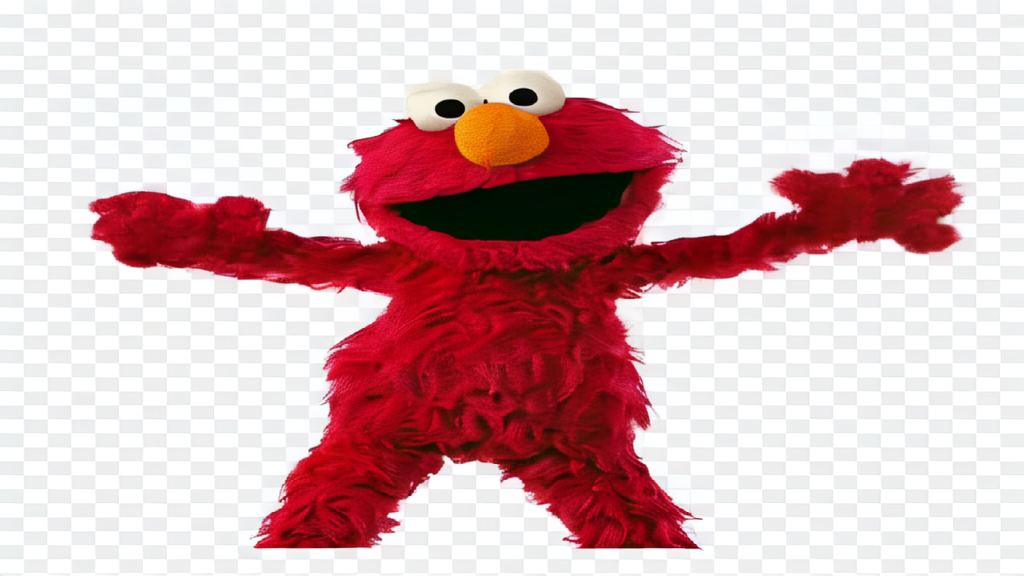

In [24]:
frames[15]

In [26]:
export_to_video(frames, "elmo.mp4", fps=7) # fps -> frames per seconds

'elmo.mp4'

In [16]:
image = load_image("elmo.jpg")

In [17]:
image.size

(736, 705)

In [18]:
elmo_frames = pipe(image, decode_chunk_size=8, generator=generator).frames[0]

  0%|          | 0/25 [00:00<?, ?it/s]

In [19]:
export_to_video(elmo_frames, "elmo.mp4", fps=7)

'elmo.mp4'

## Generating Video using another diffusion model

In [27]:
import torch
torch.cuda.empty_cache()

In [28]:
from diffusers import I2VGenXLPipeline

In [29]:
from diffusers.utils import load_image, export_to_video

In [30]:
repo_id = "ali-vilab/i2vgen-xl"

In [31]:
pipeline = I2VGenXLPipeline.from_pretrained(repo_id,
                                            torch_dtype=torch.float16, # What is the purpose?🤔
                                            variant="fp16") # floating point 16

model_index.json:   0%|          | 0.00/555 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

special_tokens_map.json:   0%|          | 0.00/588 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

scheduler_config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/2.84G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/637 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

The I2VGenXLPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


In [32]:
pipeline.enable_model_cpu_offload()

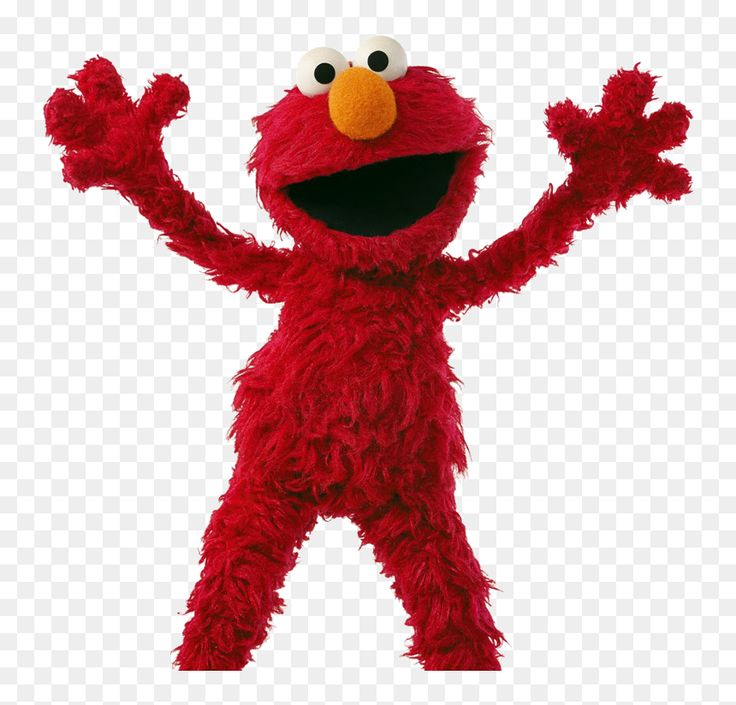

In [27]:
image

In [33]:
sea = load_image("sea.jpg")

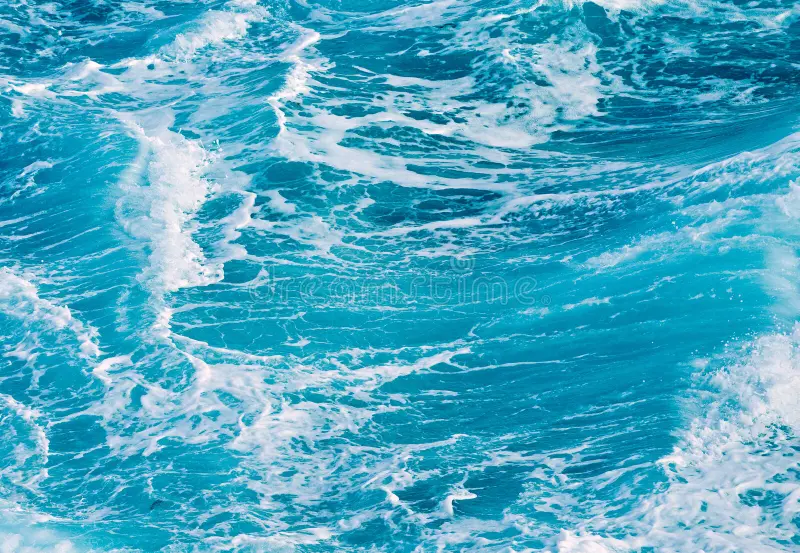

In [34]:
sea

In [35]:
prompt = "the sea waves heavily"

In [36]:
generator = torch.manual_seed(42)

In [37]:
pipeline

I2VGenXLPipeline {
  "_class_name": "I2VGenXLPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "ali-vilab/i2vgen-xl",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    "transformers",
    "CLIPVisionModelWithProjection"
  ],
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "I2VGenXLUNet"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

In [38]:
prompt

'the sea waves heavily'

In [39]:
frames = pipeline(prompt=prompt,
                  image=sea,
                  num_frames=16, # What is the number of the frames that you want generate?
                  generator=generator).frames[0]

  0%|          | 0/50 [00:00<?, ?it/s]

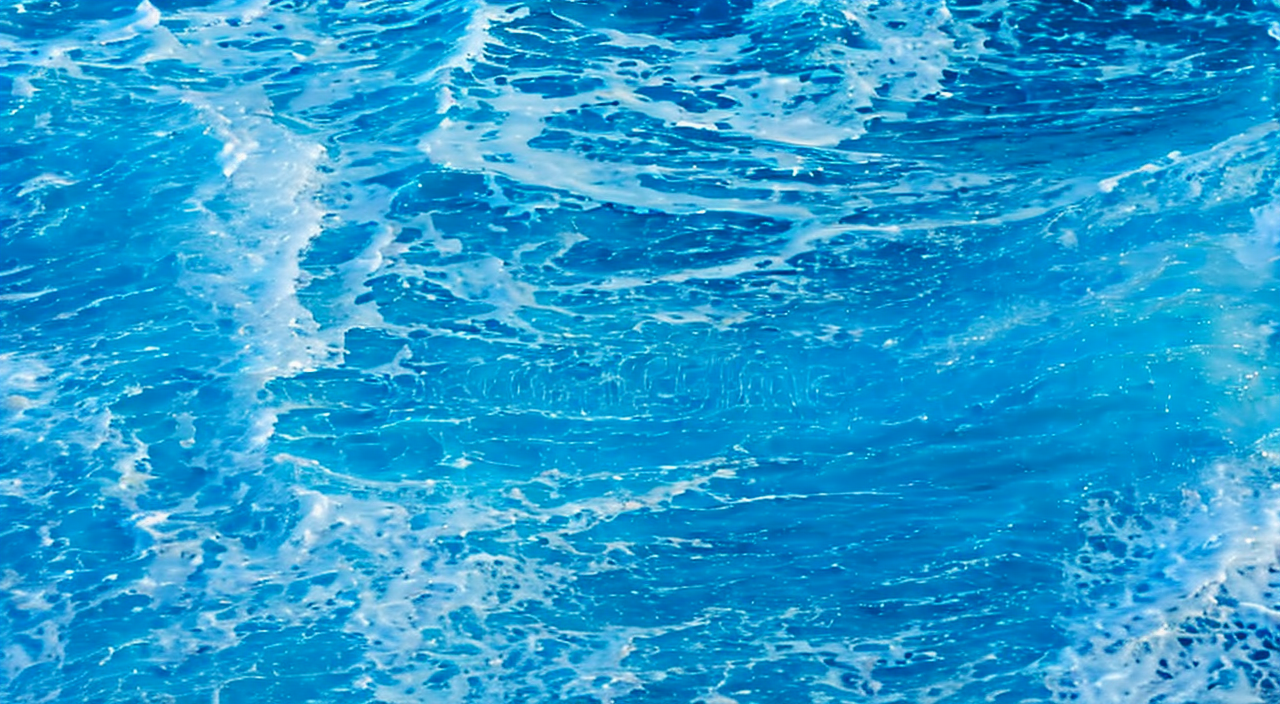

In [44]:
frames[3]

In [45]:
export_to_video(frames, "sea_waves.mp4", fps=4)

'sea_waves.mp4'